# Plot curvature: generic line

`Tr[Omega_xy]` for three SrTiO3 Wannier trials (set a: 60 WFs/30 occ full-space; set b: 30 WFs occupied-only; set c: 48 WFs/38 occ), on the Ti-displaced structure, using the center-aware position matrix reconstructed from the Wannier90 `.mmn` overlaps, along the generic reduced-coordinate line $\mathbf{k}(t) = (t, 0.30, 0.15)$, $0 \le t \le 1$.

Set `RUN_COMPUTATION = False` to skip straight to loading a previously saved run from `results/curvature_generic_line/`. (No run is cached in this repo yet -- the original script only ever saved the PNG, not the underlying curve data, to a bare path outside any per-check results directory. This notebook fixes that: it now also saves an npz of the curves themselves, under the same `results/<check>/` layout every other check in this suite uses, so a future run here is actually reloadable.)

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from pythtb import W90

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "validation").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from validation._paths import RESULTS, STO_AA_CACHE, STO_TI_Q_01A_RUN
from validation._paths import DATA
from modules import curvature as cv
from wannier.wannier_io import check_mmn_compatibility, read_wannier_checkpoint
from wannier.position_matrix import (
    apply_orbital_dependent_R_mapping,
    build_position_matrix_from_mmn,
)

## Config

In [2]:
RUN_COMPUTATION = False  # True: rebuild every trial's model and recompute the curves. False: load results/curvature_generic_line/.
POINTS = 201
OUTPUT_DIR = RESULTS / "curvature_generic_line"

PREFIX = "SrTiO3"
MODE = STO_TI_Q_01A_RUN
MMN_DONOR = DATA / "SrTiO3/Ti_Q_01A/output/181839bc889/trial_03_Sr_sp_Ti_pd_Osp/no_displacement/185119bc889"
AA_CACHE = STO_AA_CACHE

TRIALS = {
    "a": {"directory": DATA / "SrTiO3/Ti_Q_01A/output/181839bc889/trial_01_Sr_spd_Ti_spd_O_sp/no_displacement/182499bc889",
          "cache": DATA / "SrTiO3/_AA_cache/AA_trial_01_Sr_spd_Ti_spd_O_sp_mode_182499bc889_wbnone_ws1em05.npz",
          "n_occ": 30, "label": "set (a): 60 WFs, 30 occupied", "color": "C3"},
    "b": {"directory": DATA / "SrTiO3/Ti_Q_01A/output/181839bc889/trial_02_Sr_p_O_sp/no_displacement/183965bc889",
          "cache": DATA / "SrTiO3/_AA_cache/AA_trial_02_Sr_p_O_sp_mode_183965bc889_wbnone_ws1em05.npz",
          "n_occ": 30, "label": "set (b): 30 WFs, occupied-only", "color": "C0"},
    "c": {"directory": MMN_DONOR,
          "cache": DATA / "SrTiO3/_AA_cache/AA_trial_03_Sr_sp_Ti_pd_O_sp_mode_185119bc889_wbnone_ws1em05.npz",
          "n_occ": 38, "label": "set (c): 48 WFs, 38 occupied", "color": "C2"},
}
FORCED_ZEROS = (0.0, 0.3, 0.5, 0.7, 1.0)

## Helpers

In [3]:
def to_cartesian(model, curvature_reduced):
    """Convert both reduced reciprocal indices of a curvature two-form."""
    reciprocal_inverse = np.linalg.inv(np.asarray(model.recip_lat_vecs, dtype=float))
    return np.einsum("ia,jb,ab...->ij...", reciprocal_inverse, reciprocal_inverse, curvature_reduced)


def trace_omega_xy(model, pos, kpoints, n_occ):
    """Occupied-band trace of the total xy Berry curvature, and the full Cartesian tensor."""
    curvature = cv.omega(cv.connection(cv.fields(model, pos, kpoints), n_occ))
    curvature_cartesian = to_cartesian(model, curvature)
    trace = np.trace(curvature_cartesian[0, 1], axis1=-2, axis2=-1).real
    return trace, curvature_cartesian

## Build each trial and evaluate along the line

`curvature_tensors[key]` is the full Cartesian-indexed traced-occupied curvature tensor for that trial -- inspect it directly; `curves[key]` is just its `Tr Omega_xy`.

In [4]:
if RUN_COMPUTATION:
    t = np.linspace(0.0, 1.0, POINTS)
    kpoints = np.column_stack((t, np.full_like(t, 0.30), np.full_like(t, 0.15)))
    curves = {}
    curvature_tensors = {}
    for key, trial in TRIALS.items():
        directory = trial["directory"]
        check_mmn_compatibility(directory, MMN_DONOR, PREFIX)

        # min_hopping_norm = 0 keeps every hopping.  The cutoff discards hoppings
        # by magnitude, which is not a symmetry-covariant criterion, so
        # symmetry-related hoppings straddling the threshold are dropped
        # inconsistently.  Measured effect here: negligible for the curvature
        # (3rd digit) though it does improve E(k) point-group covariance ~6x.
        w90 = W90(str(directory), PREFIX)
        mp_grid = read_wannier_checkpoint(directory / f"{PREFIX}.chk")["mp_grid"]
        apply_orbital_dependent_R_mapping(w90, mp_grid)
        model = w90.model(zero_energy=0.0, min_hopping_norm=0.0)
        build_position_matrix_from_mmn(
            model, directory, PREFIX, mmn_directory=MMN_DONOR, cache=trial["cache"],
            translational_invariant_JM=False, translational_invariant_MV=False,
            R_distance_tolerance=1e-5,
        )
        pos = cv.position_terms(model, dtype=np.complex128)
        curves[key], curvature_tensors[key] = trace_omega_xy(model, pos, kpoints, trial["n_occ"])
        print(f"{key}: max |Tr Omega_xy| = {np.max(np.abs(curves[key])):.6e} A^2")

    H(R) orbital-dependent mapping (min |R + tau_right - tau_left|): 729 -> 729 R-vectors, 0.000% of the weight moved outside the input set


    SrTiO3.mmn absent; reusing AA_trial_01_Sr_spd_Ti_spd_O_sp_mode_182499bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


a: max |Tr Omega_xy| = 2.395779e-02 A^2


    H(R) orbital-dependent mapping (min |R + tau_right - tau_left|): 729 -> 721 R-vectors, 0.000% of the weight moved outside the input set


    SrTiO3.mmn absent; reusing AA_trial_02_Sr_p_O_sp_mode_183965bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


b: max |Tr Omega_xy| = 3.364779e-03 A^2


    H(R) orbital-dependent mapping (min |R + tau_right - tau_left|): 729 -> 729 R-vectors, 0.000% of the weight moved outside the input set


    SrTiO3.mmn absent; reusing AA_trial_03_Sr_sp_Ti_pd_O_sp_mode_185119bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


c: max |Tr Omega_xy| = 6.812123e-03 A^2


## Save

In [5]:
if RUN_COMPUTATION:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    npz_path = OUTPUT_DIR / "curves.npz"
    np.savez_compressed(npz_path, t=t, **{f"curve_{k}": v for k, v in curves.items()})
    print(f"saved {npz_path}")
    for key, values in curves.items():
        zero_indices = [int(round(z * (len(t) - 1))) for z in FORCED_ZEROS]
        zero_values = [values[i] for i in zero_indices]
        print(f"set ({key}): max |Tr Omega_xy| = {np.max(np.abs(values)):.8e} A^2; "
              f"forced-zero values = " + ", ".join(f"{v:+.3e}" for v in zero_values))

saved /Users/treycole/Repos/axion-phonon/validation/results/curvature_generic_line/curves.npz
set (a): max |Tr Omega_xy| = 2.39577903e-02 A^2; forced-zero values = +3.503e-08, -4.402e-08, +3.013e-08, -5.365e-08, +3.503e-08
set (b): max |Tr Omega_xy| = 3.36477887e-03 A^2; forced-zero values = -7.690e-10, -2.040e-11, +6.681e-10, +8.157e-12, -7.690e-10
set (c): max |Tr Omega_xy| = 6.81212282e-03 A^2; forced-zero values = +4.670e-08, +5.413e-08, -5.127e-08, +4.849e-08, +4.670e-08


## Load a previous run instead (skip if you just computed above)

In [6]:
if not RUN_COMPUTATION:
    npz_path = OUTPUT_DIR / "curves.npz"
    if npz_path.exists():
        with np.load(npz_path) as data:
            t = data["t"]
            curves = {k[len("curve_"):]: data[k] for k in data.files if k.startswith("curve_")}
        print(f"loaded {npz_path}")
    else:
        print(f"no saved run at {npz_path} yet -- set RUN_COMPUTATION = True to produce one.")
        t, curves = None, None

## Plot

saved /Users/treycole/Repos/axion-phonon/validation/results/curvature_generic_line/curvature_generic_line.png


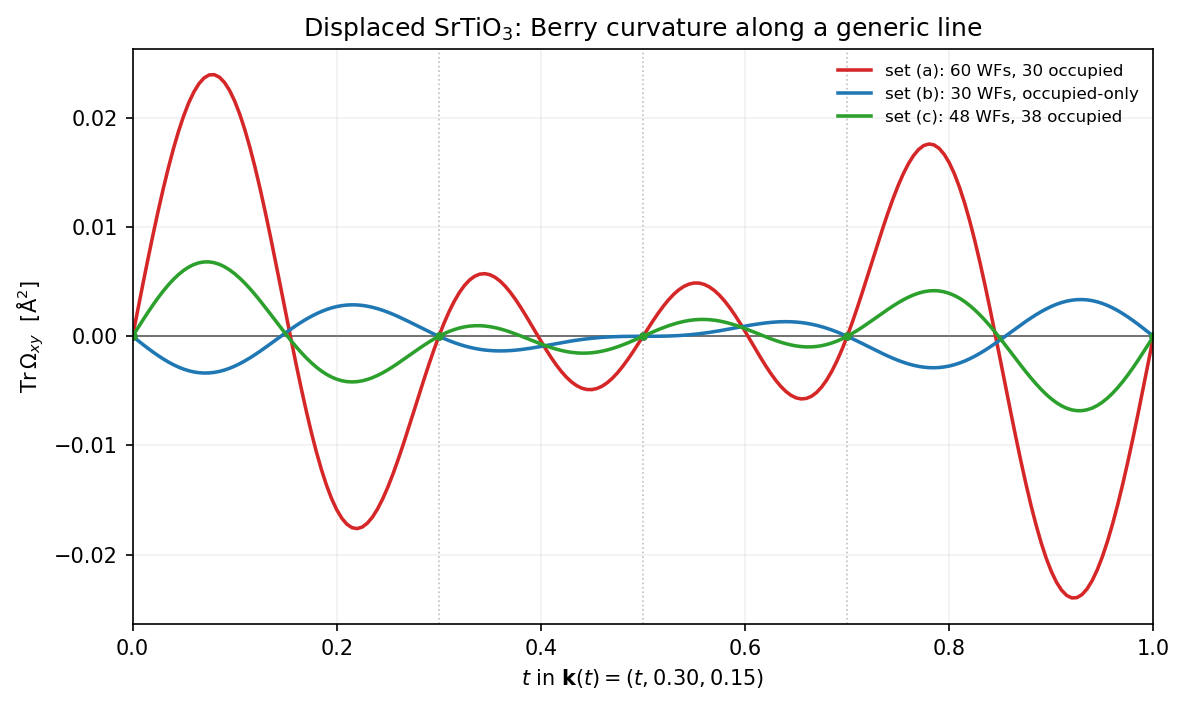

In [7]:
if curves is not None:
    fig, ax = plt.subplots(figsize=(8.0, 4.8), dpi=150)
    for zero in FORCED_ZEROS:
        ax.axvline(zero, color="0.75", linestyle=":", linewidth=0.8, zorder=0)
    ax.axhline(0.0, color="0.3", linewidth=0.8, zorder=0)
    for key, trial in TRIALS.items():
        ax.plot(t, curves[key], color=trial["color"], linewidth=1.7, label=trial["label"])
        zero_indices = [int(round(z * (len(t) - 1))) for z in FORCED_ZEROS]
        ax.plot(np.asarray(FORCED_ZEROS), curves[key][zero_indices], linestyle="none",
               marker="o", markersize=3.0, color=trial["color"])
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel(r"$t$ in $\mathbf{k}(t)=(t,0.30,0.15)$")
    ax.set_ylabel(r"$\mathrm{Tr}\,\Omega_{xy}$  [$\mathrm{\AA}^2$]")
    ax.set_title(r"Displaced SrTiO$_3$: Berry curvature along a generic line")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.18)
    fig.tight_layout()
    if RUN_COMPUTATION:
        png_path = OUTPUT_DIR / "curvature_generic_line.png"
        fig.savefig(png_path, bbox_inches="tight")
        print(f"saved {png_path}")
    plt.show()
else:
    print("nothing to plot yet.")